## NSGA-II

In [1]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation
from datetime import datetime

current_time = datetime.now()
time_str = current_time.strftime("%Y_%m_%d_%H_%M_%S")

In [2]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "nsga2",
    ]
    
    run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [00:54<00:00,  1.80s/ experiment]


Execution time: 54.46


Running cross-validation experiments: 100%|██████████| 30/30 [03:18<00:00,  6.61s/ experiment]


Execution time: 198.69


Running cross-validation experiments: 100%|██████████| 30/30 [01:28<00:00,  2.96s/ experiment]


Execution time: 89.23


=========== DATASET iris ===========



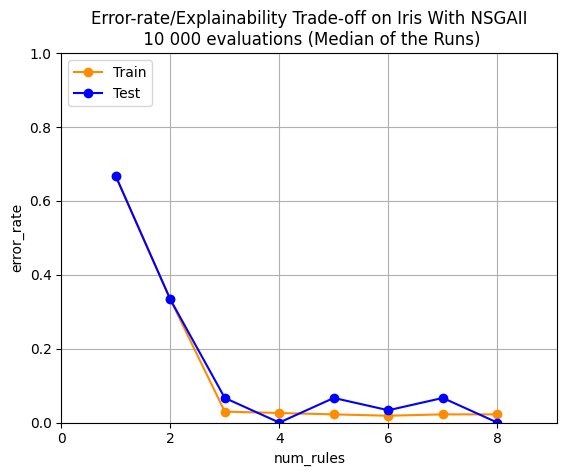

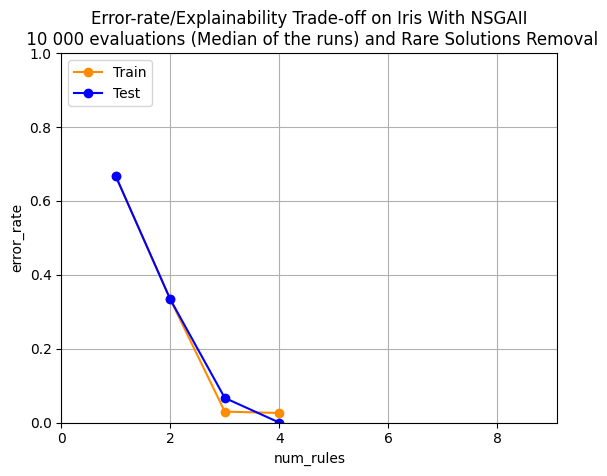

Q1:  15.362315356731415
Median :  15.75503957271576
Q3:  16.036929190158844
Average :  15.218881750106812
Std:  1.4569507411729181
=========== DATASET pima ===========



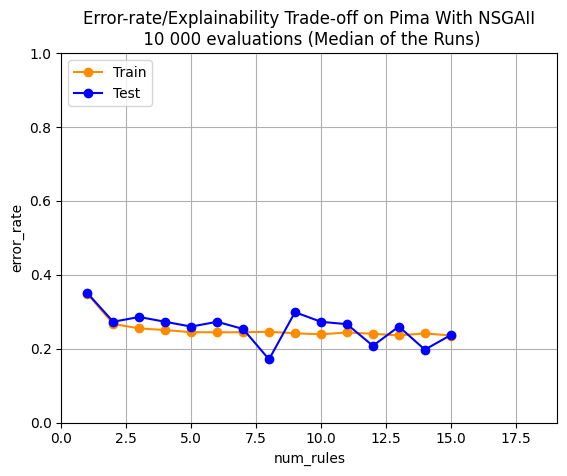

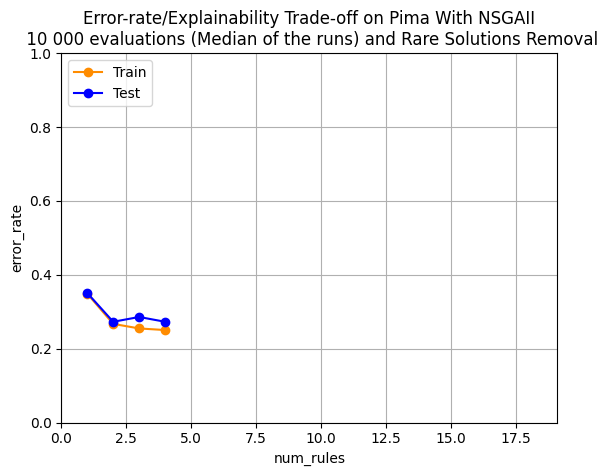

Q1:  54.58613449335098
Median :  56.8100483417511
Q3:  60.087477803230286
Average :  56.40831944147746
Std:  7.7881091177537956
=========== DATASET bupa ===========



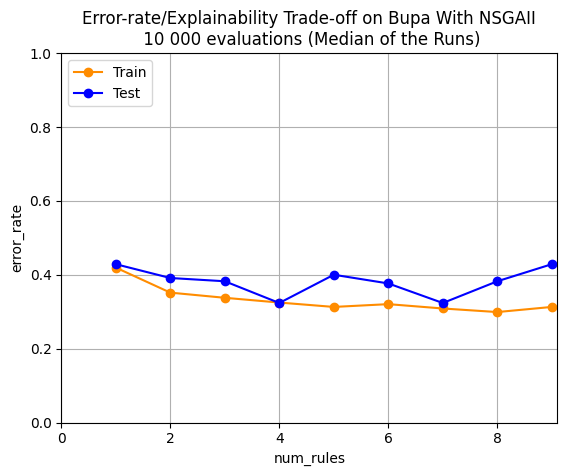

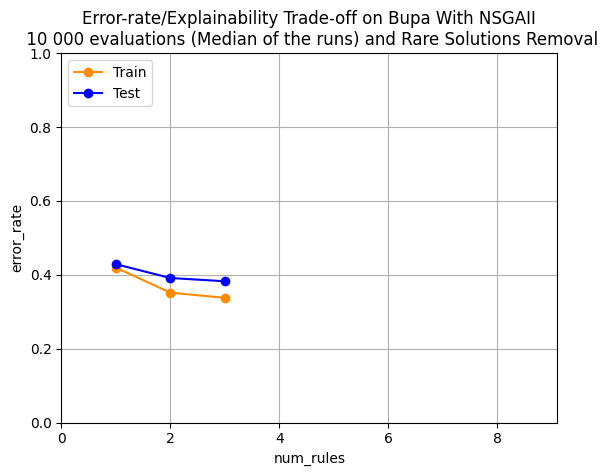

Q1:  23.780839145183563
Median :  26.248363971710205
Q3:  27.51546013355255
Average :  25.20121303399404
Std:  3.4602777458180096


In [3]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,9.1),
    "pima": (0,19.1),
    "bupa": (0,9.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]
    
    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)
        
    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()
    
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))


## MOEA/D

In [4]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "moead",
    ]

    run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [01:03<00:00,  2.10s/ experiment]


Execution time: 63.46


Running cross-validation experiments: 100%|██████████| 30/30 [02:54<00:00,  5.82s/ experiment]


Execution time: 175.11


Running cross-validation experiments: 100%|██████████| 30/30 [01:29<00:00,  2.99s/ experiment]


Execution time: 90.01


=========== DATASET iris ===========



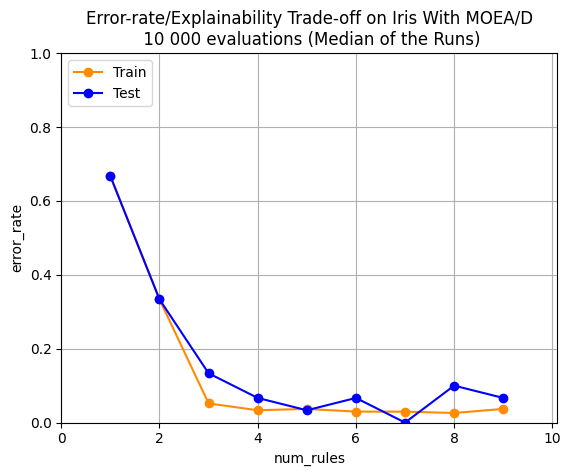

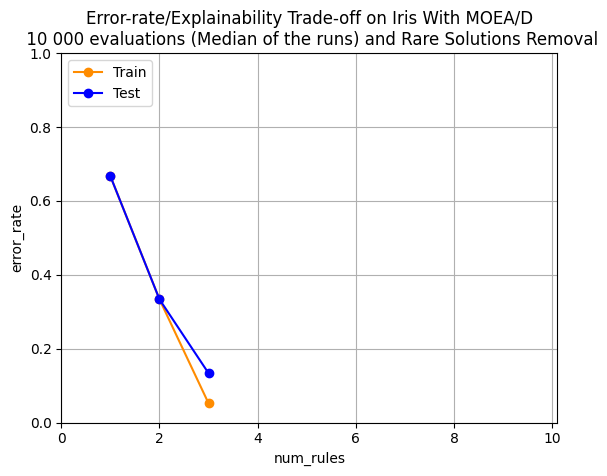

Q1:  18.874117970466614
Median :  19.331397652626038
Q3:  19.693908274173737
Average :  18.433013931910196
Std:  2.097297551040299
=========== DATASET pima ===========



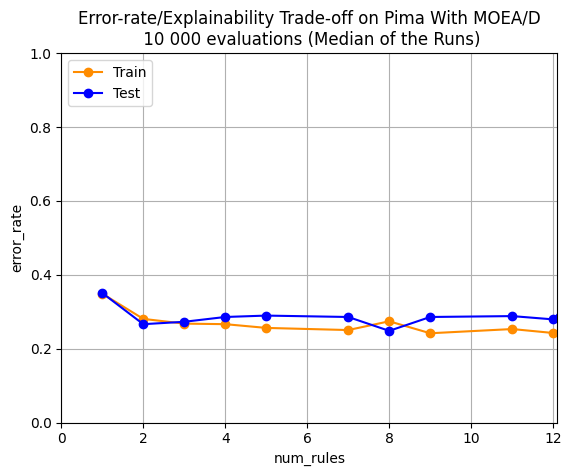

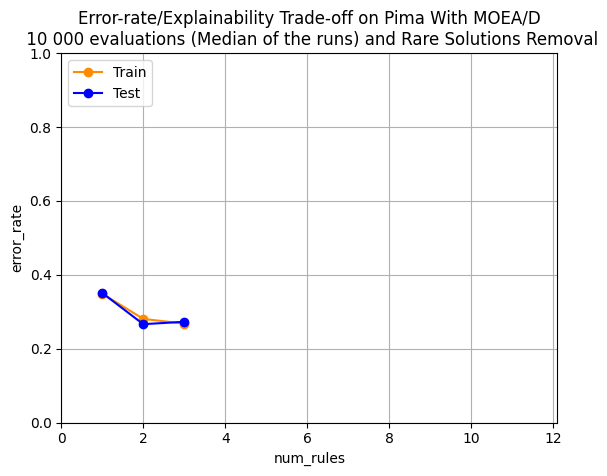

Q1:  49.44172877073288
Median :  53.07323217391968
Q3:  55.459873020648956
Average :  51.04219691753387
Std:  6.773618499043376
=========== DATASET bupa ===========



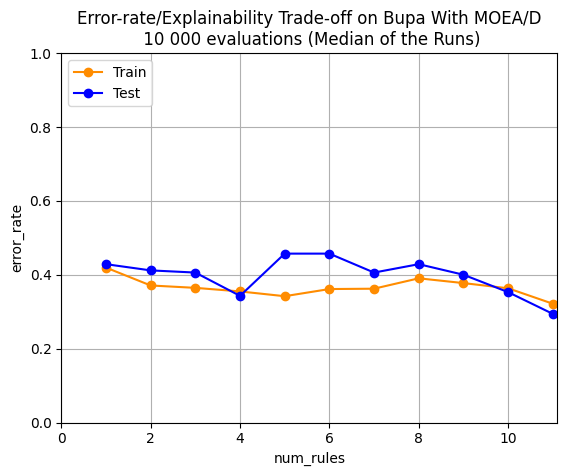

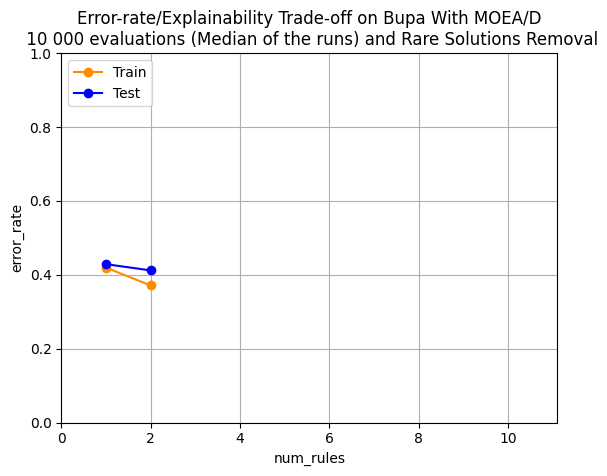

Q1:  26.31469237804413
Median :  27.412473559379578
Q3:  28.42452698945999
Average :  26.21431160767873
Std:  3.2345814458669215


In [5]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,10.1),
    "pima": (0,12.1),
    "bupa": (0,11.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]

    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)

    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()

    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))